# S12: Curvature


In [ ]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from sympy import Function, diff, Symbol, latex
from sympy.plotting import plot
from IPython.display import Math, display

# Convexity and the tangent line position

Let us consider
$$f(x) = e^x - 1,\qquad g(x) = \log(1 + x)$$

In [ ]:
# Plot together f(x) = exp(x) + 1 and g(x) = log(1 + x). Also find their tangent
# lines at x0 = 0 and plot it alongside the functions.

# Define the symbolic variable
x = sy.Symbol('x')

# Define the functions
f_x = sy.exp(x) - 1
g_x = sy.log(1 + x)

# Define the point of tangency
x0 = 0

In [ ]:
# Calculate the derivatives
df = sy.diff(f_x, x)
dg = sy.diff(g_x, x)

# Evaluate the functions and derivatives at x0
f_x0 = f_x.subs(x, x0)
g_x0 = g_x.subs(x, x0)

df_x0 = df.subs(x, x0)
dg_x0 = dg.subs(x, x0)

# Equations of the tangent lines: y = m*(x - x0) + y0
tangent_f = df_x0 * (x - x0) + f_x0
tangent_g = dg_x0 * (x - x0) + g_x0

# Print the functions and their tangent lines
print(f"f(x) = {f_x}")
print(f"Tangent to f(x) at x={x0}: y = {tangent_f}")
print(f"g(x) = {g_x}")
print(f"Tangent to g(x) at x={x0}: y = {tangent_g}")

f(x) = exp(x) - 1
Tangent to f(x) at x=0: y = x
g(x) = log(x + 1)
Tangent to g(x) at x=0: y = x


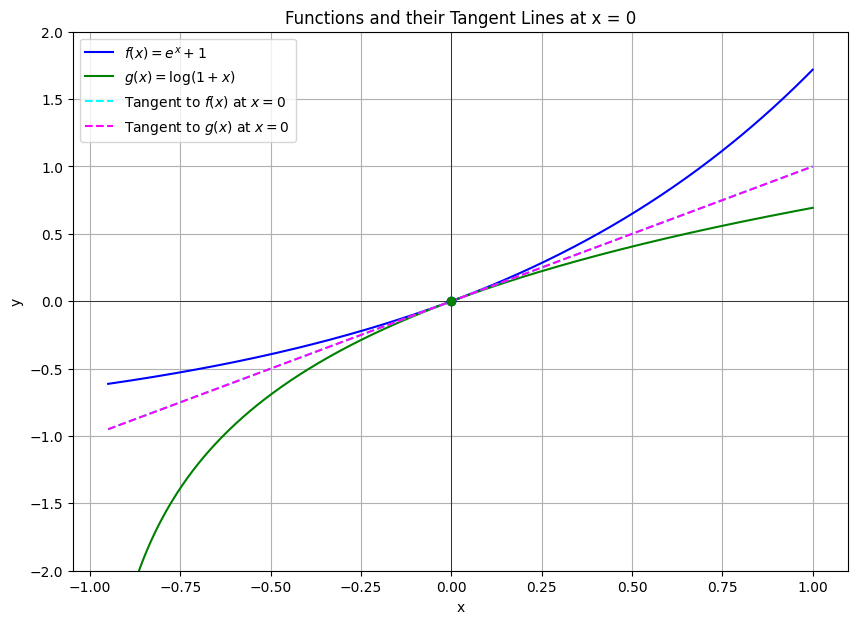

In [ ]:
# Convert sympy expressions to numerical functions for plotting
f_numeric = sy.lambdify(x, f_x, 'numpy')
g_numeric = sy.lambdify(x, g_x, 'numpy')
tangent_f_numeric = sy.lambdify(x, tangent_f, 'numpy')
tangent_g_numeric = sy.lambdify(x, tangent_g, 'numpy')

# Generate x values for plotting
x_vals = np.linspace(-0.95, 1, 400)

# Calculate y values
y_f = f_numeric(x_vals)
y_g = g_numeric(x_vals)
y_tangent_f = tangent_f_numeric(x_vals)
y_tangent_g = tangent_g_numeric(x_vals)

# Plotting
plt.figure(figsize=(10, 7))

plt.plot(x_vals, y_f, label='$f(x) = e^x + 1$', color='blue')
plt.plot(x_vals, y_g, label='$g(x) = \\log(1 + x)$', color='green')
plt.plot(x_vals, y_tangent_f, label='Tangent to $f(x)$ at $x=0$', linestyle='--', color='cyan')
plt.plot(x_vals, y_tangent_g, label='Tangent to $g(x)$ at $x=0$', linestyle='--', color='magenta')

# Mark the point of tangency
plt.scatter([x0], [f_x0], color='blue', zorder=5)
plt.scatter([x0], [g_x0], color='green', zorder=5)

plt.title('Functions and their Tangent Lines at x = 0')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.ylim(-2, 2)
plt.show()

# Convexity and higher order derivatives

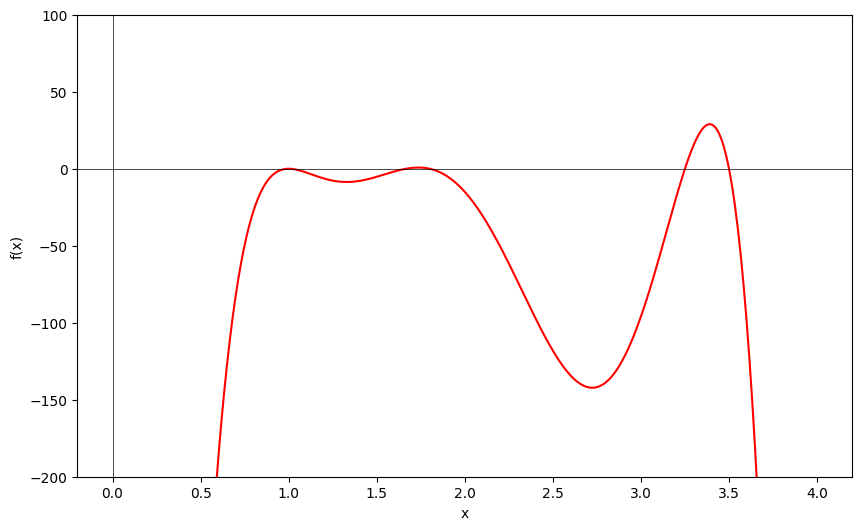

In [ ]:
# Plot the graph of f(x) = -120 x^6 + 1466x^5 - 7105x^4 + 17454x^3 - 22952x^2 + 15352x - 4000

# Define the function f(x)
f_x_poly = -120*x**6 + 1466*x**5 - 7105*x**4 + 17454*x**3 - 22952*x**2 + 15352*x - 4095

# Convert sympy expression to a numerical function for plotting
f_poly_numeric = sy.lambdify(x, f_x_poly, 'numpy')

# Generate x values for plotting
x_vals_poly = np.linspace(0, 4, 500) # Choose a range to better visualize the polynomial behavior

# Calculate y values
y_vals_poly = f_poly_numeric(x_vals_poly)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals_poly, y_vals_poly, label='$f(x)$', color='red')

#plt.title('Plot of f(x) = -120 x^6 + 1466x^5 - 7105x^4 + 17454x^3 - 22952x^2 + 15352x - 4000')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(False)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
#plt.legend()
plt.ylim(-200, 100)
plt.show()

In [ ]:
x = sy.Symbol('x')
f = 1 / (1 + x**2)
display(Math(f"f(x) = {latex(f)}"))


<IPython.core.display.Math object>

## Closed and bounded interval

We begin by looking at the restriction of this function to $A = [-1, 1]$. The following plot shows the graph of the function over that interval. We emphasize that the solid red points at both ends of the graph are indeed part of the graph. This is a consequence of the interval being closed, so that $-1$ and $1$ are part of $A$.

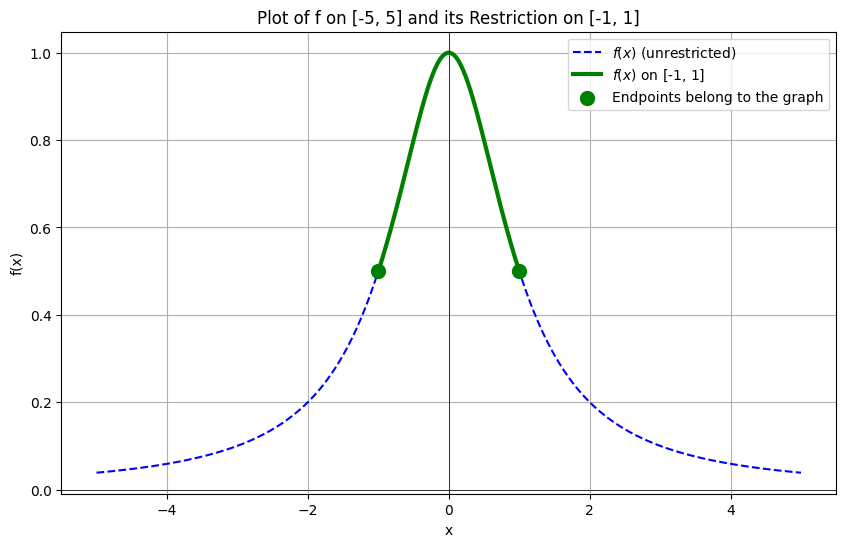

In [ ]:
# Convert sympy expression f to a numerical function for plotting with matplotlib
f_numeric = sy.lambdify(x, f, 'numpy')

plt.figure(figsize=(10, 6))

# Plot f over [-5, 5] (unrestricted)
x_full_range = np.linspace(-5, 5, 500)
y_full_range = f_numeric(x_full_range)
plt.plot(x_full_range, y_full_range, color='blue', linestyle='--', label='$f(x)$ (unrestricted)')

# Plot f over [-1, 1] (restriction)
x_restricted_range = np.linspace(-1, 1, 500)
y_restricted_range = f_numeric(x_restricted_range)
plt.plot(x_restricted_range, y_restricted_range, color='green', linewidth=3, label='$f(x)$ on [-1, 1]')

# Plot the endpoints for the restricted range at x = -1 and x = 1
endpoint_x = [-1, 1]
endpoint_y = [f_numeric(val) for val in endpoint_x]
plt.scatter(endpoint_x, endpoint_y, color='green', marker='o', s=100, zorder=5, label='Endpoints belong to the graph')

plt.title('Plot of f on [-5, 5] and its Restriction on [-1, 1]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

## Open and bounded interval

Now, let's consider the restriction of this function to the open interval $A = (-1, 1)$. The following plot shows the graph of the function over that interval. Since the interval is open, in this case the endpoints are not part of the graph.

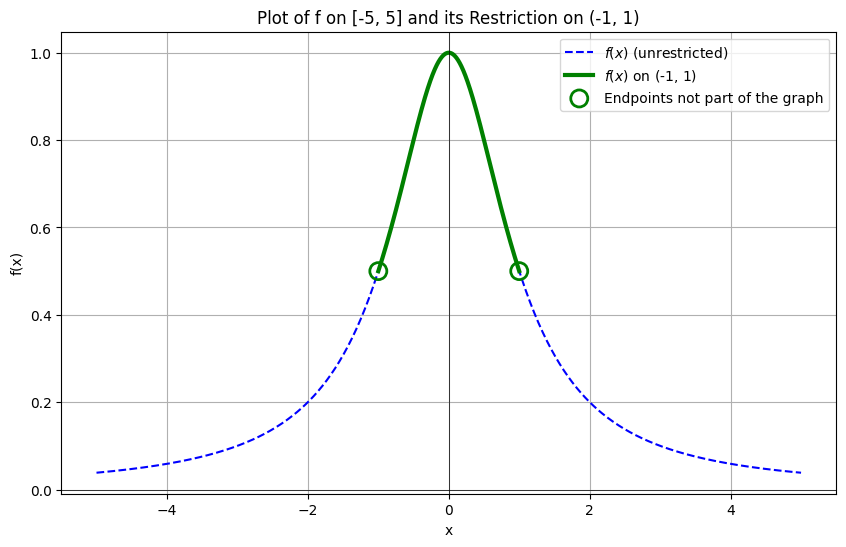

In [ ]:
import matplotlib.pyplot as plt

# Convert sympy expression f to a numerical function for plotting with matplotlib
f_numeric = sy.lambdify(x, f, 'numpy')

plt.figure(figsize=(10, 6))

# Plot f over [-5, 5] (unrestricted)
x_full_range = np.linspace(-5, 5, 500)
y_full_range = f_numeric(x_full_range)
plt.plot(x_full_range, y_full_range, color='blue', linestyle='--', label='$f(x)$ (unrestricted)')

# Plot f over (-1, 1) (restriction)
x_restricted_range = np.linspace(-1, 1, 500)
y_restricted_range = f_numeric(x_restricted_range)
plt.plot(x_restricted_range, y_restricted_range, color='green', linewidth=3, label='$f(x)$ on (-1, 1)')

# Plot the endpoints for the restricted range at x = -1 and x = 1 as open circles
endpoint_x = [-1, 1]
endpoint_y = [f_numeric(val) for val in endpoint_x]
plt.scatter(endpoint_x, endpoint_y, facecolors='none', edgecolors='green', marker='o', linewidth=2, s=150, zorder=5, label='Endpoints not part of the graph')

plt.title('Plot of f on [-5, 5] and its Restriction on (-1, 1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

# The role of the function

In the previous examples the function was continuous everywhere (continuous in $\mathbb R$), so the only difference was in the type of interval we considered. But when the function fails to be continuous at some points, things are different. Let us consider the function:
$$g(x) = \dfrac{x^2}{x^2 - 1}$$

In [ ]:
g = x**2 / (x**2 - 1)
display(Math(f"g(x) = {latex(g)}"))

<IPython.core.display.Math object>

This is the plot of the function, that you can use to answer the questions in this session's exercises.

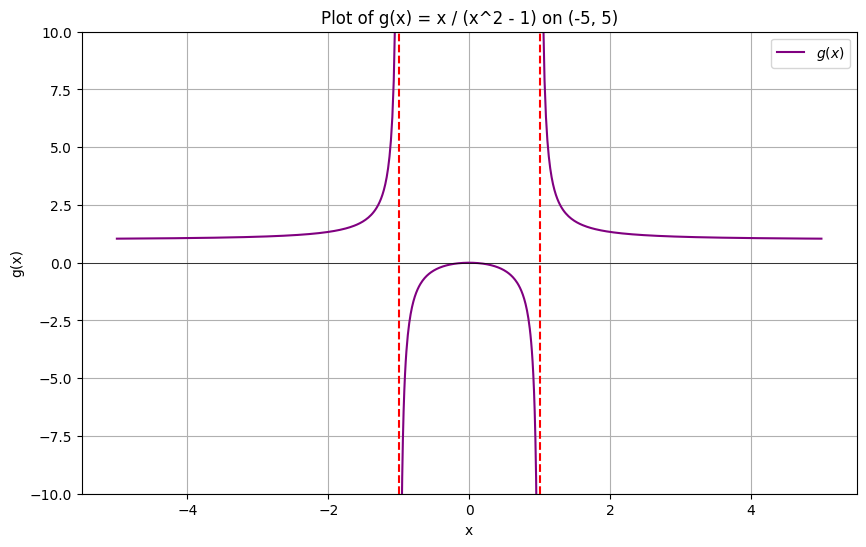

In [ ]:
import matplotlib.pyplot as plt

# Convert sympy expression g to a numerical function for plotting with matplotlib
g_numeric = sy.lambdify(x, g, 'numpy')

plt.figure(figsize=(10, 6))

# Define the intervals for plotting to avoid asymptotes
x_range_1 = np.linspace(-5, -1.01, 200) # From -5 up to just before -1
x_range_2 = np.linspace(-0.99, 0.99, 200) # From just after -1 to just before 1
x_range_3 = np.linspace(1.01, 5, 200) # From just after 1 to 5

# Plot each segment
plt.plot(x_range_1, g_numeric(x_range_1), color='purple', label='$g(x)$')
plt.plot(x_range_2, g_numeric(x_range_2), color='purple')
plt.plot(x_range_3, g_numeric(x_range_3), color='purple')

# Add vertical lines for asymptotes
plt.axvline(-1, color='red', linestyle='--')
plt.axvline(1, color='red', linestyle='--')

plt.title('Plot of g(x) = x / (x^2 - 1) on (-5, 5)')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.ylim(-10, 10) # Set y-axis limits to better view the curve around asymptotes
plt.show()

In [ ]:
h = 1 / (1 + sy.exp(1/x))
display(Math(f"h(x) = {latex(h)}"))

<IPython.core.display.Math object>

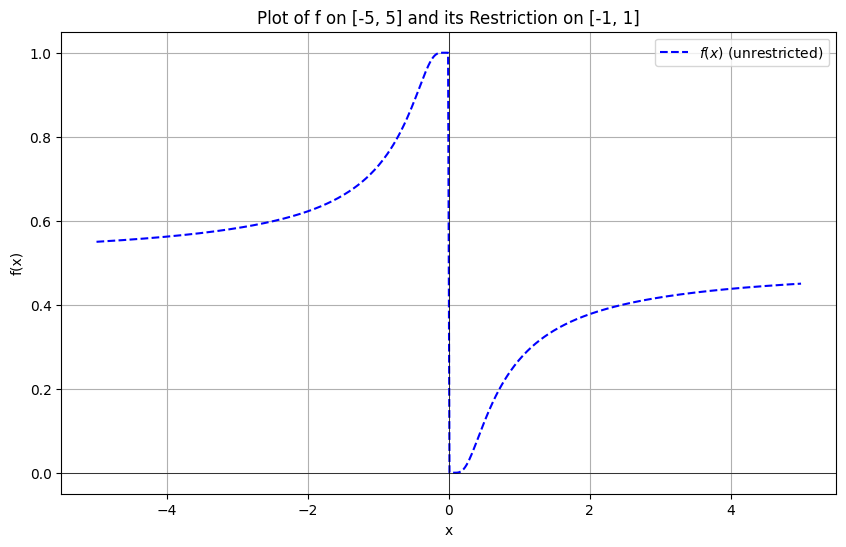

In [ ]:
# Convert sympy expression f to a numerical function for plotting with matplotlib
h_numeric = sy.lambdify(x, h, 'numpy')

plt.figure(figsize=(10, 6))

# Plot f over [-5, 5] (unrestricted)
x_full_range = np.linspace(-5, 5, 500)
y_full_range = h_numeric(x_full_range)
plt.plot(x_full_range, y_full_range, color='blue', linestyle='--', label='$f(x)$ (unrestricted)')


plt.title('Plot of f on [-5, 5] and its Restriction on [-1, 1]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

In [ ]:
f = (8 * sy.sin(x)**4 * sy.cos(x)) / (sy.sin(x)**4 + 2 * sy.cos(x)**2)

display(Math(f"f(x) = {latex(f)}"))

<IPython.core.display.Math object>

In [ ]:
df = sy.diff(f, x)
df

8*(-4*sin(x)**3*cos(x) + 4*sin(x)*cos(x))*sin(x)**4*cos(x)/(sin(x)**4 + 2*cos(x)**2)**2 - 8*sin(x)**5/(sin(x)**4 + 2*cos(x)**2) + 32*sin(x)**3*cos(x)**2/(sin(x)**4 + 2*cos(x)**2)